In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

Device: cpu


### Ручной расчет attention на 3 токенах

In [ ]:
Q = torch.tensor([[1.0, 0.0, 1.0, 0.0],
                   [0.0, 1.0, 0.0, 1.0],
                   [1.0, 1.0, 0.0, 0.0]], dtype=torch.float32)

K = torch.tensor([[1.0, 0.0, 0.0, 1.0],
                   [0.0, 1.0, 1.0, 0.0],
                   [1.0, 1.0, 1.0, 1.0]], dtype=torch.float32)

V = torch.tensor([[1.0, 2.0],
                   [3.0, 4.0],
                   [5.0, 6.0]], dtype=torch.float32)

d_k = torch.tensor(4.0, dtype=torch.float32)

scores = Q @ K.T
print("Матрица 'похожестей'\n", scores)

scores_scaled = scores / torch.sqrt(d_k)
print("Масштабирование\n", scores_scaled)

soft_scaled = torch.softmax(scores_scaled, dim=1)
soft_without_scaled = torch.softmax(scores, dim=1)

print(f"""
    Веса внимания.

    С масштабированием:
    {soft_scaled}

    Результат без:
    {soft_without_scaled}
""")

attention_scaled = soft_scaled @ V
attention_without_scaled = soft_without_scaled @ V

print(f"""
    Взвешенная сумма с масштабированием и без.

    Результат с масштабированием:
    {attention_scaled}

    Результат без:
    {attention_without_scaled}

    Разница средних: {attention_scaled.mean():.4f} | {attention_without_scaled.mean():.4f}
""")

print(f"""
    Без масштабирования распределение более 'острое':
    - максимальный вес выше: {soft_scaled[0].max():.4f} | {soft_without_scaled[0].max():.4f}
    - минимальные веса ниже: {soft_scaled[0].min():.4f} | {soft_without_scaled[0].min():.4f}
""")

Матрица 'похожестей'
 tensor([[1., 1., 2.],
        [1., 1., 2.],
        [1., 1., 2.]])
Масштабирование
 tensor([[0.5000, 0.5000, 1.0000],
        [0.5000, 0.5000, 1.0000],
        [0.5000, 0.5000, 1.0000]])

    Веса внимания.

    С масштабированием:
    tensor([[0.2741, 0.2741, 0.4519],
        [0.2741, 0.2741, 0.4519],
        [0.2741, 0.2741, 0.4519]])

    Результат без:
    tensor([[0.2119, 0.2119, 0.5761],
        [0.2119, 0.2119, 0.5761],
        [0.2119, 0.2119, 0.5761]])


    Взвешенная сумма с масштабированием и без.

    Результат с масштабированием:
    tensor([[3.3556, 4.3556],
        [3.3556, 4.3556],
        [3.3556, 4.3556]])

    Результат без:
    tensor([[3.7284, 4.7284],
        [3.7284, 4.7284],
        [3.7284, 4.7284]])

    Разница средних: 3.8556 | 4.2284


    Без масштабирования распределение более 'острое':
    - максимальный вес выше: 0.4519 | 0.5761
    - минимальные веса ниже: 0.2741 | 0.2119



### Реализация scaled dot-product attention

In [3]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Scaled dot-product attention.

    Аргументы:
        Q: (batch, seq_q, d_k)
        K: (batch, seq_k, d_k)
        V: (batch, seq_k, d_v)
        mask: (batch, seq_q, seq_k) или (seq_q, seq_k), 0 = маскировать

    Возвращает:
        output: (batch, seq_q, d_v)
        weights: (batch, seq_q, seq_k)
    """
    d_k = Q.shape[-1]
    d_k_tn = torch.tensor(d_k, dtype=torch.float32)
    
    scores = torch.matmul(Q, K.transpose(-2, -1))
    scaled = scores / torch.sqrt(d_k_tn)

    if mask is not None:
        scaled = scaled.masked_fill(mask == 0, -1e9)
    
    weights = torch.softmax(scaled, dim=-1)
    output = torch.matmul(weights, V)
    
    return output, weights

output, weights = scaled_dot_product_attention(Q, K, V)

print("Без маски:")

print(f"Q shape: {Q.shape}")
print(f"K shape: {K.shape}")
print(f"V shape: {V.shape}")
print(f"Output shape: {output.shape}")
print(f"Weights shape: {weights.shape}")
print(f"Output: \n{output}")
print(f"Attention weights:\n{weights}")

row_sums = weights.sum(dim=-1)
print(f"Проверка суммы вероятностей:\n{row_sums}")

print("\nС маской:")

mask = torch.ones(3, 3, dtype=torch.float32)
mask[:, 1] = 0
output, weights = scaled_dot_product_attention(Q, K, V, mask=mask)

print(f"Output shape: {output.shape}")
print(f"Weights shape: {weights.shape}")
print(f"Output: \n{output}")
print(f"Attention weights:\n{weights}")

row_sums = weights.sum(dim=-1)
print(f"Проверка суммы вероятностей:\n{row_sums}")

Без маски:
Q shape: torch.Size([3, 4])
K shape: torch.Size([3, 4])
V shape: torch.Size([3, 2])
Output shape: torch.Size([3, 2])
Weights shape: torch.Size([3, 3])
Output: 
tensor([[3.3556, 4.3556],
        [3.3556, 4.3556],
        [3.3556, 4.3556]])
Attention weights:
tensor([[0.2741, 0.2741, 0.4519],
        [0.2741, 0.2741, 0.4519],
        [0.2741, 0.2741, 0.4519]])
Проверка суммы вероятностей:
tensor([1., 1., 1.])

С маской:
Output shape: torch.Size([3, 2])
Weights shape: torch.Size([3, 3])
Output: 
tensor([[3.4898, 4.4898],
        [3.4898, 4.4898],
        [3.4898, 4.4898]])
Attention weights:
tensor([[0.3775, 0.0000, 0.6225],
        [0.3775, 0.0000, 0.6225],
        [0.3775, 0.0000, 0.6225]])
Проверка суммы вероятностей:
tensor([1., 1., 1.])


### Маскирование: causal mask и padding mask

In [ ]:
def causal_mask(seq_len):
    """Нижнетреугольная маска (1 = разрешено, 0 = запрещено)."""
    return torch.tril(torch.ones(seq_len, seq_len, dtype=torch.float32))

def padding_mask(lengths, max_len):
    """Маска для padding: lengths --- длины последовательностей в батче."""
    positions = torch.arange(max_len).expand(len(lengths), -1)
    return positions < lengths.unsqueeze(1)

_, without_mask = scaled_dot_product_attention(Q, K, V, mask=None)
print(f"Attention weights without mask:\n{without_mask}")

causal_m = causal_mask(seq_len=K.shape[0])
_, with_causal = scaled_dot_product_attention(Q, K, V, mask=causal_m) 
print(f"\nAttention weights with causal mask:\n{with_causal}")

params = [
    (torch.tensor([0, 2, 3]), 3),
    (torch.tensor([2, 1, 2]), 3),
    (torch.tensor([1, 2, 2]), 3),
]

masks = []
for lengths, seq_len in params:
    mask = padding_mask(lengths, seq_len)[0]
    masks.append(mask)
padding_m_slice = torch.stack(masks)

padding_m = padding_mask(*params[0])
_, with_padding = scaled_dot_product_attention(Q, K, V, mask=padding_m) 
print(f"\nAttention weights with padding mask:\n{with_padding}")

Attention weights without mask:
tensor([[0.2741, 0.2741, 0.4519],
        [0.2741, 0.2741, 0.4519],
        [0.2741, 0.2741, 0.4519]])

Attention weights with causal mask:
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.2741, 0.2741, 0.4519]])

Attention weights with padding mask:
tensor([[0.3333, 0.3333, 0.3333],
        [0.5000, 0.5000, 0.0000],
        [0.2741, 0.2741, 0.4519]])


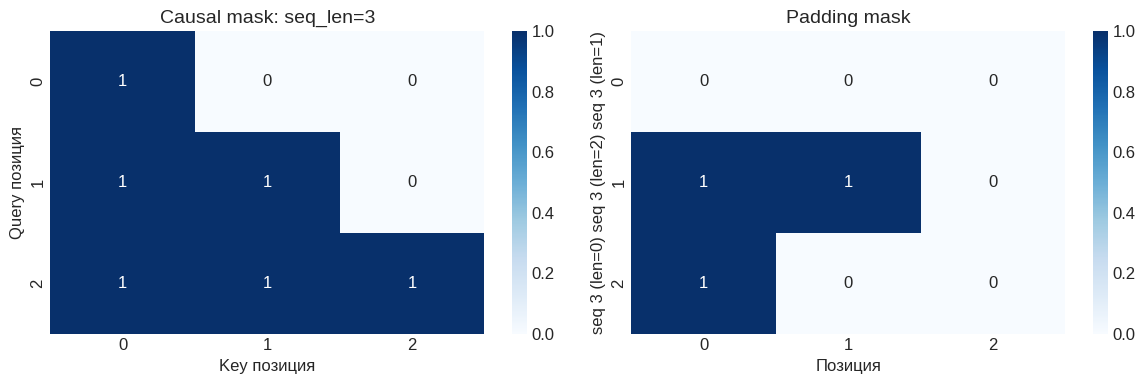

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(causal_m, annot=True, cmap="Blues", ax=axes[0])
axes[0].set_title(f"Causal mask: seq_len={K.shape[0]}")
axes[0].set_xlabel("Key позиция")
axes[0].set_ylabel("Query позиция")

sns.heatmap(padding_m_slice, annot=True, cmap="Blues", ax=axes[1])
axes[1].set_title("Padding mask")
axes[1].set_xlabel("Позиция")
axes[1].set_ylabel("seq 3 (len=0) seq 3 (len=2) seq 3 (len=1)")

plt.tight_layout()
plt.show()

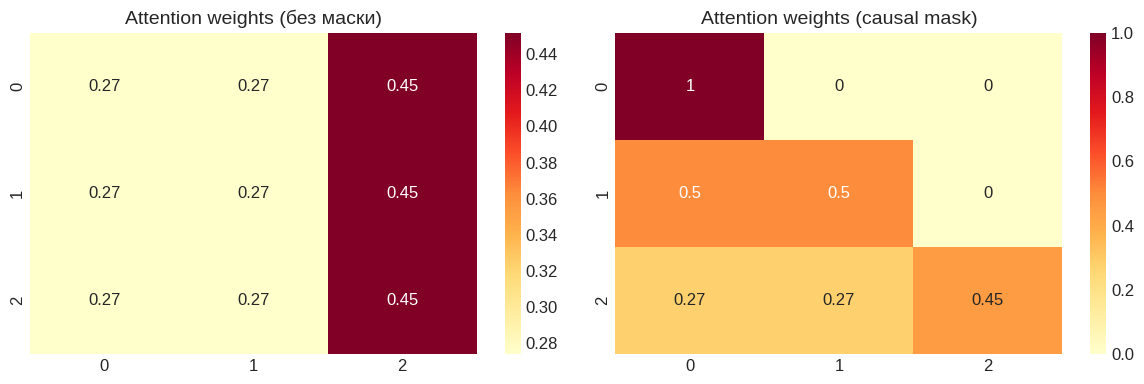

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(without_mask, annot=True, cmap="YlOrRd", ax=axes[0])
axes[0].set_title("Attention weights (без маски)")

sns.heatmap(with_causal, annot=True, cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Attention weights (causal mask)")

plt.tight_layout()
plt.show()

**ВЫВОД:**  

`causal mask` обнуляет внимание к будущим позициям, что необходимо для авторегрессивной генерации.

### Позиционное кодирование

## Сводная таблица

| Переменная | Форма | Суть |
|---|---|---|
| `X` | (1, 4, 16) | Случайные эмбеддинги без PE |
| `out_orig` | (1, 4, 16) | Attention в прямом порядке |
| `perm` | (4,) | Перестановка: [2, 0, 3, 1] Конкретное значение [2, 0, 3, 1] не принципиально, подойдёт любая перестановка|
| `inv_perm` | (4,) | Обратная перестановка: argsort(perm) |
| `out_perm_restored` | (1, 4, 16) | Attention на перемешанном X, возвращённый в исходный порядок |
| `diff_no_pe` | скаляр | Разница ≈ 0 -> инвариантность |
| `pe_emb` | (1, 4, 16) | Синусоидальное позиционное кодирование |
| `X_pe` | (1, 4, 16) | Эмбеддинги + PE (оригинальный порядок) |
| `X_perm_pe` | (1, 4, 16) | Перемешанные эмбеддинги + PE новых позиций |
| `out_pe` | (1, 4, 16) | Attention с PE (оригинальный порядок) |
| `out_perm_pe` | (1, 4, 16) | Attention с PE (перемешанный порядок) |
| `out_perm_pe_restored` | (1, 4, 16) | Восстановленный в исходный порядок |
| `diff_with_pe` | скаляр | Разница >> 0 -> PE ломает инвариантность |

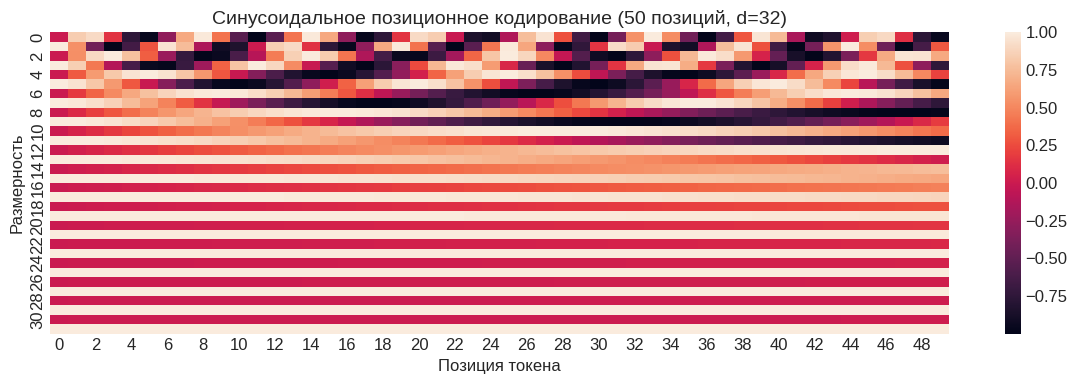

Максимальная разница без PE: 0.000000047
Без PE: attention инвариантен к перестановкам  [OK]
Максимальная разница с PE: 0.1841
С PE: перестановка МЕНЯЕТ результат  [OK]



In [ ]:
def sinusoidal_pe(max_len, d_model):
    """Синусоидальное позиционное кодирование."""
    pe = torch.zeros(max_len, d_model, dtype=torch.float32)
    pos = torch.arange(max_len).unsqueeze(1)
    i = torch.arange(0, d_model, 2) / 2

    pe[:, 0::2] = torch.sin(pos / (10000 ** (2 * i / d_model)))
    pe[:, 1::2] = torch.cos(pos / (10000 ** (2 * i / d_model)))

    return pe

max_len, d = 50, 32
pe = sinusoidal_pe(max_len, d)

plt.figure(figsize=(12, 4))

sns.heatmap(pe.T)
plt.title(f"Синусоидальное позиционное кодирование ({max_len} позиций, d={d})")
plt.xlabel("Позиция токена")
plt.ylabel("Размерность")

plt.tight_layout()
plt.show()

d_model = 16
seq_len = 4

X = torch.randn(1, 4, 16)

Q = K = V = X
out_orig, _ = scaled_dot_product_attention(Q, K, V)

perm = torch.tensor([2, 0, 3, 1])
X_perm = X[:, perm, :]

inv_perm = torch.argsort(perm)

Q_perm = K_perm = V_perm = X_perm
out_perm, _ = scaled_dot_product_attention(Q_perm, K_perm, V_perm)

out_perm_restored = out_perm[:, inv_perm, :]
diff_no_pe = torch.abs(out_orig - out_perm_restored).mean().item()

pe_emb = sinusoidal_pe(seq_len, d_model).unsqueeze(0)
X_pe = X + pe_emb
X_perm_pe = X_perm + pe_emb

Q_pe = K_pe = V_pe = X_pe
out_pe, _ = scaled_dot_product_attention(Q_pe, K_pe, V_pe)

Q_perm_pe = K_perm_pe = V_perm_pe = X_perm_pe
out_perm_pe, _ = scaled_dot_product_attention(Q_perm_pe, K_perm_pe, V_perm_pe)

out_perm_pe_restored = out_perm_pe[:, inv_perm, :]
diff_with_pe = torch.abs(out_pe - out_perm_pe_restored).mean().item()

wo_pe = "[OK]" if diff_no_pe < 1e-6 else "[NOT OK]"
w_pe = "[OK]" if diff_with_pe > 1e-2 else "[NOT OK]"

print(
    f"Максимальная разница без PE: {diff_no_pe:.9f}\n"
    f"Без PE: attention инвариантен к перестановкам  {wo_pe}\n"
    f"Максимальная разница с PE: {diff_with_pe:.4f}\n"
    f"С PE: перестановка МЕНЯЕТ результат  {w_pe}\n"
)

### Multi-head attention с нуля

In [8]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads

        assert d_model % n_heads == 0, "d_model должен целочисленно делиться на n_heads"
        self.d_k = d_model // n_heads

        self.w_q = nn.Linear(d_model, d_model, bias=False)
        self.w_k = nn.Linear(d_model, d_model, bias=False)
        self.w_v = nn.Linear(d_model, d_model, bias=False)
        self.w_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, mask=None):
        """
        x: (batch, seq_len, d_model)
        mask: (batch, seq_len, seq_len) или None
        """
        batch, seq_len, _ = x.shape
        
        q = self.w_q(x)
        k = self.w_k(x)
        v = self.w_v(x)

        q = q.view(batch, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        k = k.view(batch, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        v = v.view(batch, seq_len, self.n_heads, self.d_k).transpose(1, 2)

        output, weights = scaled_dot_product_attention(q, k, v, mask)

        output = output.permute(0, 2, 1, 3).reshape(batch, seq_len, self.d_model)
        output = self.w_o(output)

        weights = weights.reshape(batch, self.n_heads, seq_len, seq_len)

        return output, weights

d_model, n_heads = 32, 4
mha = MultiHeadAttention(d_model, n_heads)

x = torch.randn(2, 6, d_model)
output, weights = mha(x)

print(f"Вход:     {x.shape}")
print(f"Выход:    {output.shape}")
print(f"Веса:     {weights.shape}  (batch, n_heads, seq_q, seq_k)")
print()

total_params = sum(p.numel() for p in mha.parameters())
print(f"Число параметров MHA: {total_params:,}")
print(f"  W_Q: {d_model}x{d_model} = {d_model*d_model}")
print(f"  W_K: {d_model}x{d_model} = {d_model*d_model}")
print(f"  W_V: {d_model}x{d_model} = {d_model*d_model}")
print(f"  W_O: {d_model}x{d_model} = {d_model*d_model}")
print(f"  Итого: 4 * {d_model}^2 = {4*d_model*d_model}")

Вход:     torch.Size([2, 6, 32])
Выход:    torch.Size([2, 6, 32])
Веса:     torch.Size([2, 4, 6, 6])  (batch, n_heads, seq_q, seq_k)

Число параметров MHA: 4,096
  W_Q: 32x32 = 1024
  W_K: 32x32 = 1024
  W_V: 32x32 = 1024
  W_O: 32x32 = 1024
  Итого: 4 * 32^2 = 4096


### Один Transformer Encoder Layer с нуля

In [9]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.0):
        super().__init__()
        self.self_attn = MultiHeadAttention(
            d_model=d_model,
            n_heads=n_heads,
        )

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model),
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None, return_attn_weights=False):
        attn_out, attn_weights = self.self_attn(x, mask=mask)
        x = self.norm1(x + self.dropout(attn_out))

        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        
        if return_attn_weights:
            return x, attn_weights

        return x

d_model, n_heads, d_ff = 64, 4, 256
enc_layer = TransformerEncoderLayer(d_model, n_heads, d_ff)

x = torch.randn(2, 10, d_model)
output, weights = enc_layer(x, return_attn_weights=True)

print(f"Вход:  {x.shape}")
print(f"Выход: {output.shape}")
assert output.shape == x.shape, "Форма должна сохраняться!"
print("[OK] Форма сохраняется.")
print()

total = sum(p.numel() for p in enc_layer.parameters())
mha_p = sum(p.numel() for p in enc_layer.self_attn.parameters())
ffn_p = sum(p.numel() for p in enc_layer.ffn.parameters())
norm_p = (
    sum(p.numel() for p in enc_layer.norm1.parameters())
    + sum(p.numel() for p in enc_layer.norm2.parameters())
)

print("Параметры Transformer Encoder Layer:")
print(f"  MHA:       {mha_p:,}")
print(f"  FFN:       {ffn_p:,}")
print(f"  LayerNorm: {norm_p:,}")
print(f"  ИТОГО:     {total:,}")

Вход:  torch.Size([2, 10, 64])
Выход: torch.Size([2, 10, 64])
[OK] Форма сохраняется.

Параметры Transformer Encoder Layer:
  MHA:       16,384
  FFN:       33,088
  LayerNorm: 256
  ИТОГО:     49,728


### RNN vs Transformer: дальние зависимости

In [10]:
SEQ_LEN = 50

def generate_first_last_data(n, seq_len=SEQ_LEN):
    """Генерация: label = 1, если первый и последний элементы совпадают."""
    X = torch.randint(0, 2, (n, seq_len), dtype=torch.float32)
    y = (X[:, 0] == X[:, -1]).long()

    return X.unsqueeze(-1), y

X_train, y_train = generate_first_last_data(2000)
X_test, y_test = generate_first_last_data(500)
train_balance = y_train.float().mean().item()
test_balance = y_test.float().mean().item()

print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Test: {X_test.shape}, {y_test.shape}")

print(f"\nБаланс классов (train): {train_balance:.2f}")
print(f"Баланс классов (test): {test_balance:.2f}")

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)

class RNNClassifier(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32, n_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, n_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        _, h_n = self.gru(x)
        h_last = h_n[-1]
        out = self.fc(h_last)

        return out

class TransformerClassifier(nn.Module):
    def __init__(self, input_dim=1, d_model=32, n_heads=4, d_ff=64, n_layers=2):
        super().__init__()
        self.input = nn.Linear(input_dim, d_model)

        self.encoder_layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, n_heads, d_ff)
            for _ in range(n_layers)
        ])

        self.fc = nn.Linear(d_model, 2)
        
    def forward(self, x):
        x = self.input(x)

        for layer in self.encoder_layers:
            x = layer(x)

        x = x.mean(dim=1)
        out = self.fc(x)

        return out

def calculate_accuracy(y_pred, y_true):
    return (y_pred == y_true).sum().item() / y_true.shape[0]

def train_classifier(model: nn.Module, name: str, epochs=20):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters())
    
    acc_history = []
    for epoch in range(epochs):
        model.train()

        for X_train, y_train in train_loader:
            optimizer.zero_grad()
            
            y_pred = model(X_train)
            loss = criterion(y_pred, y_train)

            loss.backward()
            optimizer.step()

        model.eval()

        batch_test_acc = []
        with torch.no_grad():
            for X_test, y_test in test_loader:
                outputs = model(X_test)
                _, y_pred = torch.max(outputs, 1)
                acc = calculate_accuracy(y_pred, y_test)
                batch_test_acc.append(acc)

        test_acc = sum(batch_test_acc) / len(batch_test_acc)
        acc_history.append(test_acc)

        if (epoch + 1) % 5 == 0:
            print(
                f"{name} "
                f"эпоха {epoch+1}/{epochs} "
                f"test_acc: {test_acc:.4f}"
            )

    return acc_history

print("\n--- RNN (GRU) ---")
rnn_accs = train_classifier(
    model=RNNClassifier(),
    name="RNN",
)

print("\n--- Transformer ---")
tr_accs = train_classifier(
    model=TransformerClassifier(),
    name="Transformer",
)

print(
    "\nИтоговая accuracy:\n"
    f"RNN: {sum(rnn_accs) / len(rnn_accs):.4f}\n"
    f"Transformer: {sum(tr_accs) / len(tr_accs):.4f}\n"
)

Train: torch.Size([2000, 50, 1]), torch.Size([2000])
Test: torch.Size([500, 50, 1]), torch.Size([500])

Баланс классов (train): 0.49
Баланс классов (test): 0.46

--- RNN (GRU) ---
RNN эпоха 5/20 test_acc: 0.5395
RNN эпоха 10/20 test_acc: 0.5512
RNN эпоха 15/20 test_acc: 0.5395
RNN эпоха 20/20 test_acc: 0.5430

--- Transformer ---
Transformer эпоха 5/20 test_acc: 0.4605
Transformer эпоха 10/20 test_acc: 0.4957
Transformer эпоха 15/20 test_acc: 0.5395
Transformer эпоха 20/20 test_acc: 0.5395

Итоговая accuracy:
RNN: 0.5421
Transformer: 0.5189



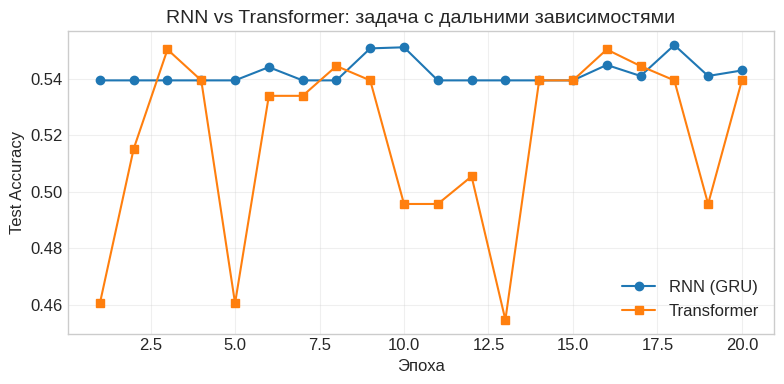

In [11]:
plt.figure(figsize=(8, 4))

plt.plot(range(1, 21), rnn_accs, "o-", label="RNN (GRU)")
plt.plot(range(1, 21), tr_accs, "s-", label="Transformer")

plt.xlabel("Эпоха")
plt.ylabel("Test Accuracy")
plt.title("RNN vs Transformer: задача с дальними зависимостями")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Мини decoder-only Transformer (char-level LM)

In [ ]:
CONTEXT_LEN = 32

corpus = (
    "Нейронные сети представляют собой мощный инструмент машинного обучения. "
    "Глубокое обучение позволяет автоматически извлекать признаки из данных. "
    "Архитектура Transformer произвела революцию в обработке естественного языка. "
    "Механизм внимания позволяет модели фокусироваться на релевантных частях входа. "
    "Языковые модели предсказывают следующий токен на основе контекста. "
    "Обучение нейронных сетей требует больших объемов данных и вычислительных ресурсов. "
    "Регуляризация помогает избежать переобучения модели на тренировочных данных. "
    "Функция потерь определяет качество предсказаний модели. "
    "Градиентный спуск является основным методом оптимизации параметров. "
    "Обратное распространение ошибки позволяет эффективно вычислять градиенты. "
)

char_data = {char: id for id, char in enumerate(set(corpus))}
ids_data = {id: char for char, id in char_data.items()}

encode_corp = torch.tensor([char_data[char] for char in corpus]).long()

def make_sequences(data, ctx_len):
    X, Y = [], []
    for i in range(len(data) - ctx_len):
        X.append(data[i:i+ctx_len])
        Y.append(data[i+1:i+ctx_len+1])

    return torch.stack(X), torch.stack(Y)

X_lm, Y_lm = make_sequences(encode_corp, CONTEXT_LEN)

print(f"Y_lm.min(): {Y_lm.min()}, Y_lm.max(): {Y_lm.max()}")

X_Y_pairs = list(zip(X_lm, Y_lm))
lm_loader = DataLoader(X_Y_pairs, batch_size=16, shuffle=True)

class CharTransformerLM(nn.Module):
    def __init__(self, vocab_size, d_model=64, n_heads=4, d_ff=128, n_layers=2, max_len=256):
        super().__init__()
        self.d_model = d_model
        self.emb = nn.Embedding(vocab_size, d_model)
        self.pe = sinusoidal_pe(max_len, d_model)

        self.layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, n_heads, d_ff)
            for _ in range(n_layers)
        ])

        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x, return_attn_weights=False):
        _, seq_len = x.shape
        
        x = self.emb(x) + self.pe[:seq_len, :].unsqueeze(0)

        weights = []
        mask = causal_mask(seq_len)
        for layer in self.layers:
            if return_attn_weights:
                x, attn_weights = layer(x, mask, return_attn_weights=True)
                weights.append(attn_weights)
            else:
                x = layer(x, mask)

        out = self.lm_head(x)
        if return_attn_weights:
            return out, weights

        return out

vocab_size = len(char_data)
model_lm = CharTransformerLM(vocab_size).to(device)
optimizer = optim.Adam(model_lm.parameters())
criterion = nn.CrossEntropyLoss()

print(
    f"Длина корпуса: {len(corpus)} символов\n"
    f"Размер словаря: {len(char_data)}\n"
    f"Обучающих примеров: {len(X_Y_pairs)}\n"
)

epochs = 50
lm_losses = []
for epoch in range(epochs):
    model_lm.train()

    batch_loss = []
    for X_train, y_train in lm_loader:
        optimizer.zero_grad()

        y_pred = model_lm(X_train)
        loss = criterion(y_pred.view(-1, vocab_size), y_train.view(-1))

        loss.backward()
        optimizer.step()

        batch_loss.append(loss.item())

    lm_losses.append(
        sum(batch_loss) / len(batch_loss)
    )

    if (epoch + 1) % 10 == 0:
        cur_loss = sum(lm_losses) / len(lm_losses)
        print(f"Эпоха {epoch+1}/{epochs}: loss: {cur_loss:.4f}")

Y_lm.min(): 0, Y_lm.max(): 50
Длина корпуса: 725 символов
Размер словаря: 51
Обучающих примеров: 693

Эпоха 10/50: loss: 1.1675
Эпоха 20/50: loss: 0.6786
Эпоха 30/50: loss: 0.5034
Эпоха 40/50: loss: 0.4132
Эпоха 50/50: loss: 0.3584


In [ ]:
def get_ids(chars):
    return torch.tensor([[char_data[char] for char in chars]]).long()

def generate_text(model, seed_text, length=150, temperature=1.0):
    model.eval()

    chars = [char for char in seed_text]
    ids = get_ids(chars)
    
    with torch.no_grad():
        for _ in range(length):
            pred = model(ids)
            pred = pred[0, -1, :] / temperature

            probs = torch.softmax(pred, dim=-1)
            next_id = torch.multinomial(probs, 1).item()
            next_char = ids_data[next_id]

            chars.append(next_char)

            ids = get_ids(chars)

    return ''.join(chars)

print("\n--- Сгенерированный текст (temperature=0.8) ---")

seed = "Нейронные сети "
generated = generate_text(model_lm, seed, length=200, temperature=0.8)

print(generated)


--- Сгенерированный текст (temperature=0.8) ---
Нейронные сети представляют собой мобобобобощм м метиетиетиетиетиетичетиетиетиетиетиетичетия пощмополь моль мощнаший ощна тиежашиель ой покашиметий пучежаший пучетима. кий пучетимель пй пжаший покий окий оль киеля о


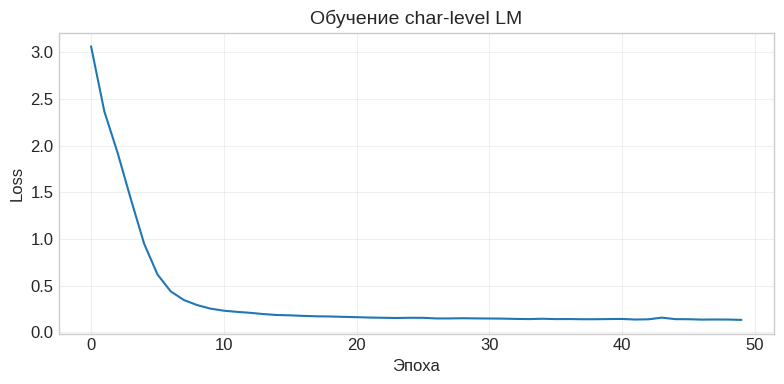

In [14]:
plt.figure(figsize=(8, 4))

sns.lineplot(lm_losses)

plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Обучение char-level LM")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Визуализация attention и стратегии декодирования

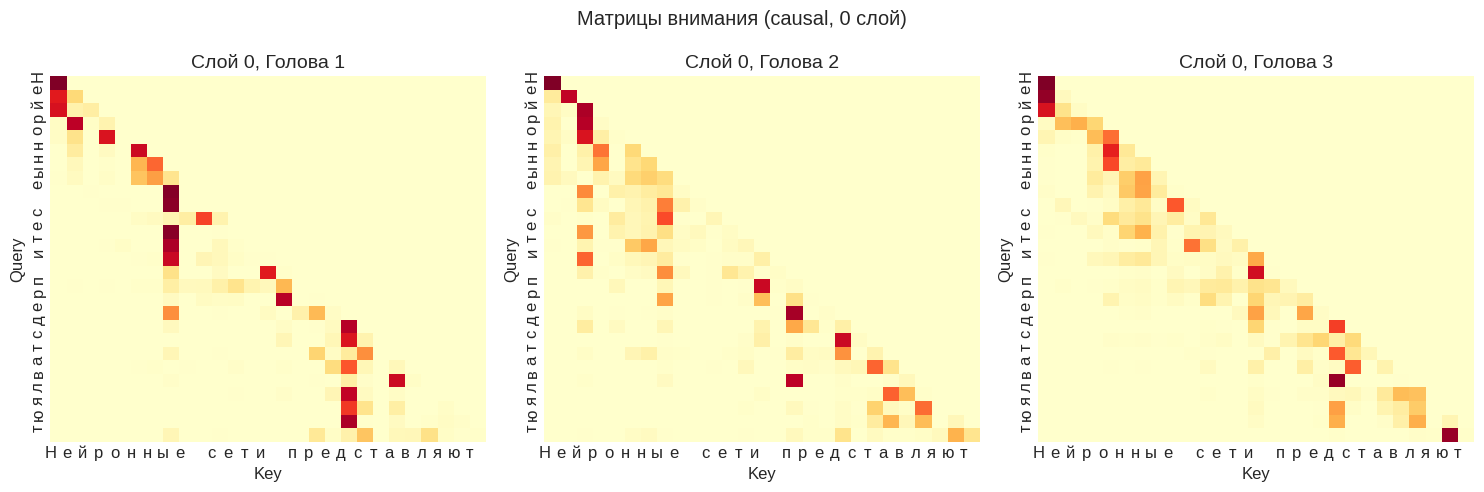

GREEDY:
Глубокое обучение позволяет автоматодетодетолелях фыкант фоде нти нннтоли. птоди. помыкананыканананаютом ыкающи пощий подий подий подий подий поделязыкransforansformera

TEMPERATURE = 0.5 (более детерминированный):
Глубокое обучение позволяет автоматом одетодетоляеичеичентоденннтоденннтодетоделяели. поманыкананасляеиче паныыыыыщичнаныканыканыканыканныканыканыканыканыче пязыканыки 

TEMPERATURE = 1.5 (более случайный):
Глубокое обучение позволекатетеюуерисф провжа о провм ововогонт оо оши. од оля онт уют оых пч пучнюциюъщsforaoюsfыычыкскскасклязннияент овядимодмаюцииforrрыкиющннскдзиa

TOP-K (k=5):
Глубокое обучение позволяет автоматодетоматодежаныки поли побеичентобеичнтоделянюцияиянаныкиииииияеющияе нающияющиииязыказыканый ом пкиязыкаший паных детий иязый ий ий 

TOP-K (k=3):
Глубокое обучение пойраненировочных ддтксля маннтелий мелий мелий и ий поданнютелимычмелимелий имелимеля мелимелязых мелий мелязелиманть мелязвых дскrmeransforзвыканть 

 (так и не смог понять, где ошибка

In [ ]:
sample_text = "Нейронные сети представляют"
sample_ids = torch.tensor([[char_data[char] for char in sample_text]]).long()

model_lm.eval()
with torch.no_grad():
    _, attn_all = model_lm(sample_ids, return_attn_weights=True)

n_show_heads = 3
show_layer = 0
fig, axes = plt.subplots(1, n_show_heads, figsize=(5 * n_show_heads, 5))
labels = list(sample_text)

for h_idx in range(n_show_heads):
    attn_matrix = attn_all[show_layer][0, h_idx, :, :]

    sns.heatmap(attn_matrix, cmap="YlOrRd", cbar=False, ax=axes[h_idx])

    axes[h_idx].set_title(f"Слой {show_layer}, Голова {h_idx+1}")
    axes[h_idx].set_xlabel("Key")
    axes[h_idx].set_ylabel("Query")

    axes[h_idx].set_xticks(range(len(sample_text)))
    axes[h_idx].set_xticklabels(list(sample_text))
    axes[h_idx].set_yticks(range(len(sample_text)))
    axes[h_idx].set_yticklabels(list(sample_text))

plt.suptitle(f"Матрицы внимания (causal, {show_layer} слой)")
plt.tight_layout()
plt.show()

def generate_greedy(model, seed_text, length=100):
    """Жадное декодирование: всегда выбирается argmax."""
    chars = [char for char in seed_text]
    ids = get_ids(chars)

    model.eval()
    with torch.no_grad():
        for _ in range(length):
            pred = model(ids)
            next_id = pred[0, -1, :].argmax().item()

            chars.append(ids_data[next_id])

            ids = get_ids(chars)

    return ''.join(chars)

def generate_temperature(model, seed_text, length=100, temperature=1.0):
    """Сэмплирование с температурой."""
    chars = [char for char in seed_text]
    ids = get_ids(chars)

    model.eval()
    with torch.no_grad():
        for _ in range(length):
            pred = model(ids)
            pred = pred[0, -1, :] / temperature

            probs = torch.softmax(pred, dim=-1)
            next_id = torch.multinomial(probs, 1).item()
            next_char = ids_data[next_id]

            chars.append(next_char)

            ids = get_ids(chars)

    return ''.join(chars)

def generate_top_k(model, seed_text, length=100, k=5, temperature=1.0):
    """Top-k сэмплирование."""
    chars = [char for char in seed_text]
    ids = get_ids(chars)

    model.eval()
    with torch.no_grad():
        for _ in range(length):
            pred = model(ids)
            pred = pred[0, -1, :] / temperature

            top_k_values, top_k_indices = torch.topk(pred, k)
            probs = torch.zeros_like(pred)
            probs[top_k_indices] = torch.softmax(top_k_values, dim=-1)

            next_id = torch.multinomial(probs, 1).item()
            next_char = ids_data[next_id]

            chars.append(next_char)

            ids = get_ids(chars)

    return ''.join(chars)

seed = "Глубокое обучение "

print("=" * 60)
print("GREEDY:")
print(generate_greedy(model_lm, seed, 150))
print()


print("=" * 60)
print("TEMPERATURE = 0.5 (более детерминированный):")
print(generate_temperature(model_lm, seed, 150, temperature=0.5))
print()

print("=" * 60)
print("TEMPERATURE = 1.5 (более случайный):")
print(generate_temperature(model_lm, seed, 150, temperature=1.5))
print()

print("=" * 60)
print("TOP-K (k=5):")
print(generate_top_k(model_lm, seed, 150, k=5))
print()

print("=" * 60)
print("TOP-K (k=3):")
print(generate_top_k(model_lm, seed, 150, k=3))
print()

print("""
Анализ:
  - Greedy: наиболее детерминированный, часто зацикливается.
  - Низкая температура: близко к greedy, но с небольшой вариативностью.
  - Высокая температура: более разнообразный, но менее когерентный текст.
  - Top-k: ограничивает выбор k наиболее вероятных символов,
    баланс между разнообразием и качеством.
""")